In [1]:

import cv2, vpi
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt

from torchvision.transforms.v2.functional import perspective
from torchvision.transforms import functional as F

/home/zh/.local/lib/python3.10/site-packages/onnxruntime/capi/onnxruntime_validation.py:114: UserWarning: WARNING: failed to get cudart_version from onnxruntime build info.
  warnings.warn("WARNING: failed to get cudart_version from onnxruntime build info.")


(-0.5, 1919.5, 1199.5, -0.5)

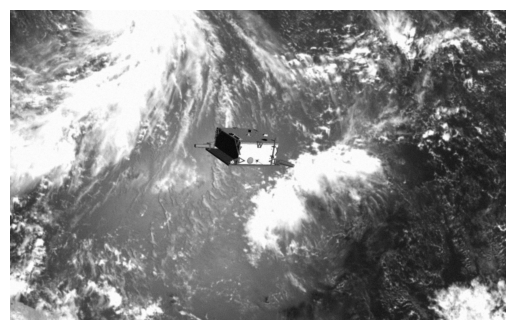

In [3]:
image_cv = cv2.imread('img008549.jpg')
# 用plotlib显示原图
plt.imshow(cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB))
plt.axis('off')

In [2]:
wrap_matrix = np.array([[1, 0, 1], [0, 1, 1], [0, 0, 1]], dtype=np.float32)

In [3]:
image_cv = cv2.imread('img008549.jpg')

In [4]:
image_cv = cv2.warpPerspective(image_cv, wrap_matrix, (image_cv.shape[1], image_cv.shape[0]))

In [34]:
%%timeit global image_cv
cv2.warpPerspective(image_cv, wrap_matrix, (image_cv.shape[1], image_cv.shape[0]))

2.39 ms ± 191 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


(-0.5, 1919.5, 1199.5, -0.5)

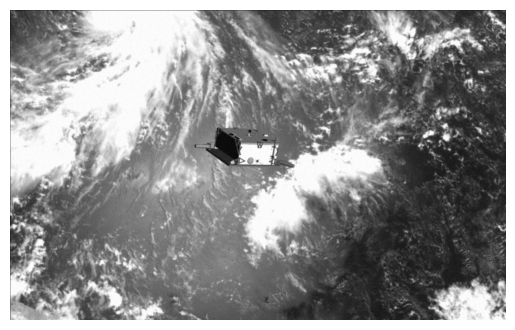

In [5]:
# 用plotlib显示原图
plt.imshow(cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB))
plt.axis('off')

In [6]:
image_cv = cv2.imread('img008549.jpg', cv2.IMREAD_GRAYSCALE)
image_cv.shape

(1200, 1920)

In [7]:
with vpi.Backend.CUDA:
    image_cv = vpi.asimage(image_cv).convert(vpi.Format.NV12_ER)

In [8]:
wrap_matrix = np.array([[1, 0, 50], [0, 1, 50], [0, 0, 1]], dtype=np.float32)

In [9]:
%%timeit global image_cv
with vpi.Backend.CUDA:
    for i in range(30):
        image_cv = image_cv.perspwarp(wrap_matrix)

2.51 ms ± 21.4 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [16]:
with image_cv.rlock_cpu() as Data:
    image_0 = Data[0]
    image_1 = Data[1]
print(image_0.shape, image_1.shape)

(1200, 1920) (600, 960, 2)


In [17]:
with image_cv.rlock_cpu() as outData:
    image_cv = outData[0]


(-0.5, 1919.5, 1199.5, -0.5)

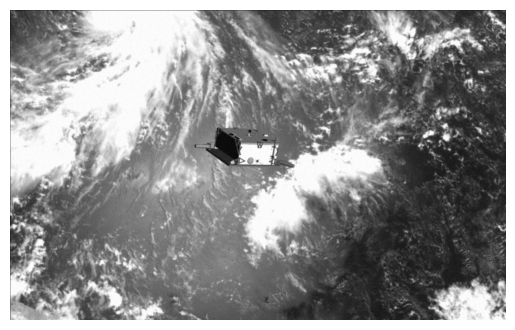

In [18]:
plt.imshow(cv2.cvtColor(image_cv, cv2.COLOR_GRAY2RGB))
plt.axis('off')